# Implementazione

## Dependencies Import

In [1]:
%pip install --quiet torchvision pytorch-lightning albumentations numpy torchsummary torchmetrics torch scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
#Dependencies import

import os
import sys
import json
import requests
import tarfile

#Data management imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Augmentation and preprocessing imports
import albumentations as A
from albumentations.pytorch import ToTensorV2

#Deep learning imports
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torch.utils.data import DataLoader, Dataset

#Torchvision
import torchvision
from torchvision import transforms, datasets, models

import torch
import torch.nn as nn
import torch.optim as optim

c:\Repositories\proai\course7-cv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Repositories\proai\course7-cv\.venv\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
#DNNHelper module download

# Standard library
import os
import requests
import zipfile


url = "https://raw.githubusercontent.com/crypto-infinity/proai/refs/heads/course6-pytorch/project/dnnhelper/__init__.py"
directory = "./dnnhelper"
file_path = os.path.join(directory, "__init__.py")

if not os.path.exists(directory):
    os.makedirs("./dnnhelper", exist_ok = True)
    response = requests.get(url)

    if response.status_code == 200:
        with open(file_path, "wb") as file:
            file.write(response.content)

    else:
        raise Exception(f"Errore durante il download del file: {response.status_code}")

#Importing the DNNHelper module
from dnnhelper import Helper

In [20]:
# Dataset download

def download_dataset(
        url="https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz", 
        tar_name="progetto-finale-flowes.tar.gz", 
        extracted_file_name="progetto-finale-flowes"
                     ):
    """
    Downloads and extracts the dataset if it does not already exist.
    """

    if not os.path.exists("dataset"):
        print("Downloading dataset...")
        file = requests.get(url)

        if file.status_code == 200:
            with open(tar_name, "wb") as f:
                f.write(file.content)
                print("Download complete!")

            if not os.path.exists(extracted_file_name):
                print("Extracting dataset...")
                with tarfile.open(tar_name, "r:gz") as f:
                    f.extractall(path=extracted_file_name)
                    print("Extraction complete!")

                    # Change directory to the extracted folder
                    os.rename(os.path.join(extracted_file_name,extracted_file_name), "dataset")

                    # Remove all metadata files (._)

                    for root, dirs, files in os.walk("dataset"):
                        for file in files:
                            if file.startswith("._"):
                                os.remove(os.path.join(root, file))
                
            os.remove(tar_name)

        else:
            print("Failed to download dataset. Status code:", file.status_code)


In [21]:
download_dataset()

Download complete!
Extracting dataset...
Extraction complete!


In [22]:
#PyTorch DEVICE setup

DEVICE = Helper.set_device()
print(f"Using device: {DEVICE}")

Using device: cpu


In [23]:
#Random seed for reproducibility

SEED = 56

Helper.set_seed(SEED)
print(f"Random seed set to: {SEED}")

Random seed set to: 56


In [24]:
# Wrapper for Albumentations transforms

class Transforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

## Dataset Import

In [25]:
#Dataset creation

TRAINSET_PATH = './dataset/train/'
VALSET_PATH = './dataset/val/'
TESTSET_PATH = './dataset/test/'

trainset = torchvision.datasets.ImageFolder(root=TRAINSET_PATH)

In [29]:
# Preprocessing default template

default_preprocessing_pipeline = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])

Struttura del dataset: ['.DS_Store', 'daisy', 'dandelion']


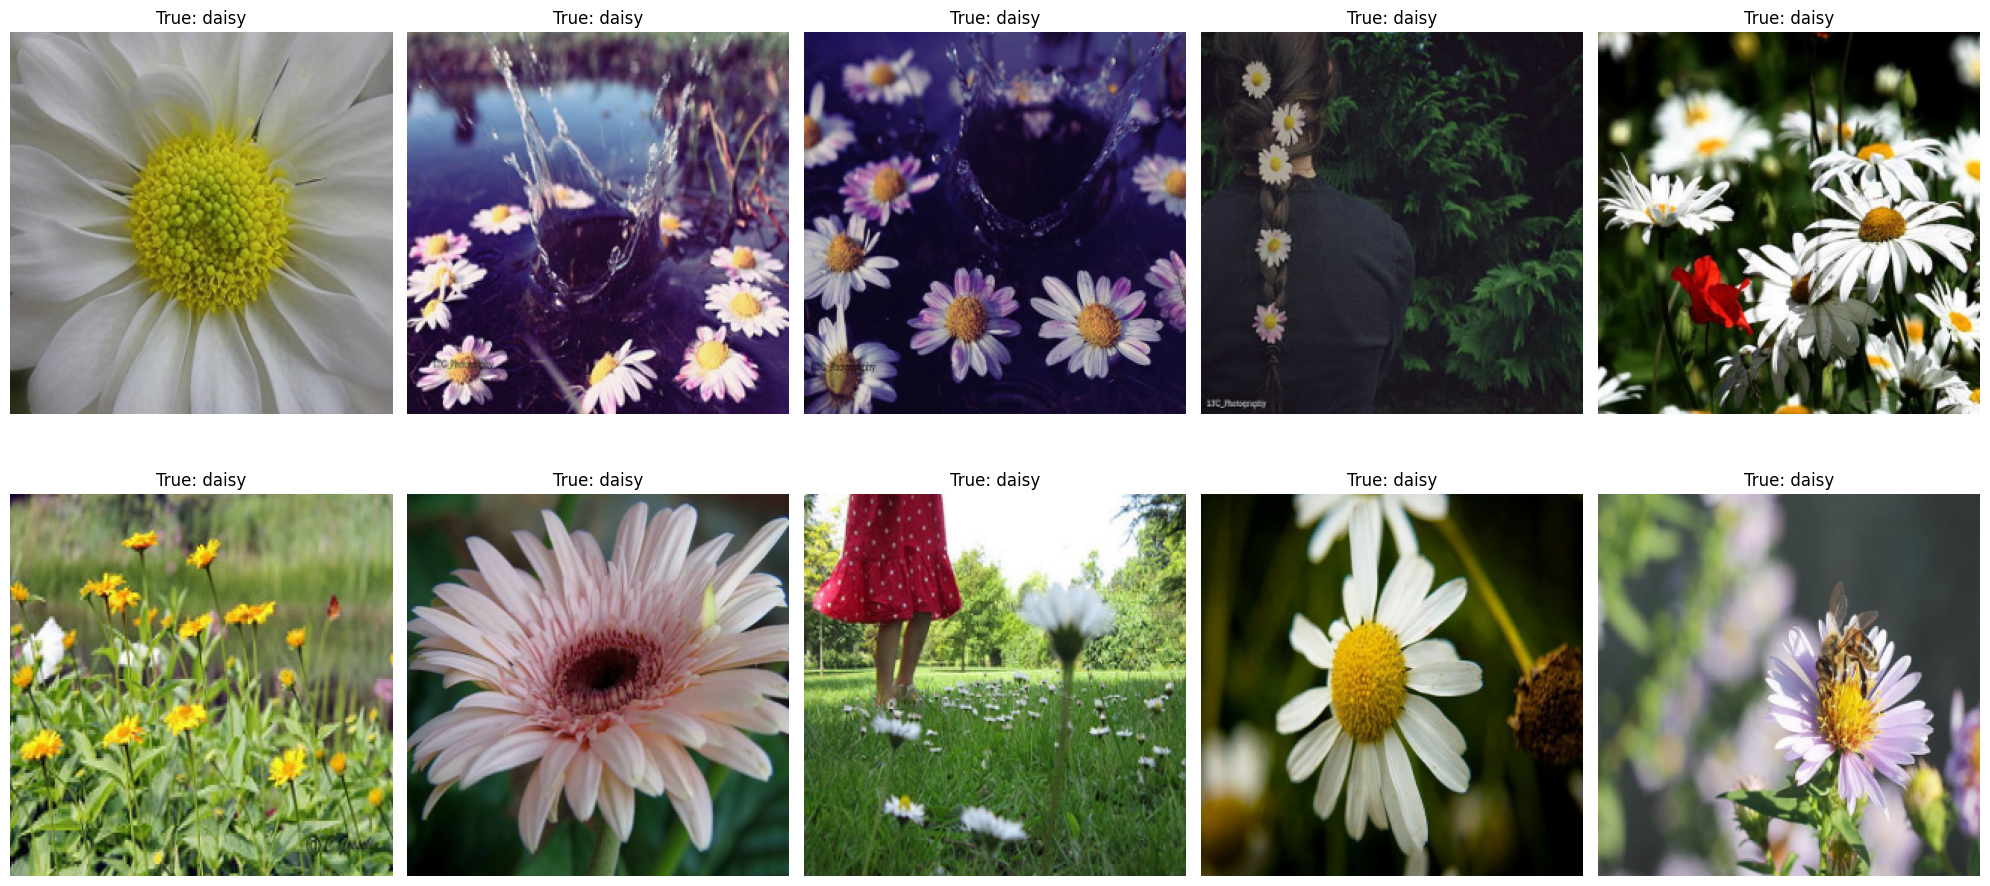

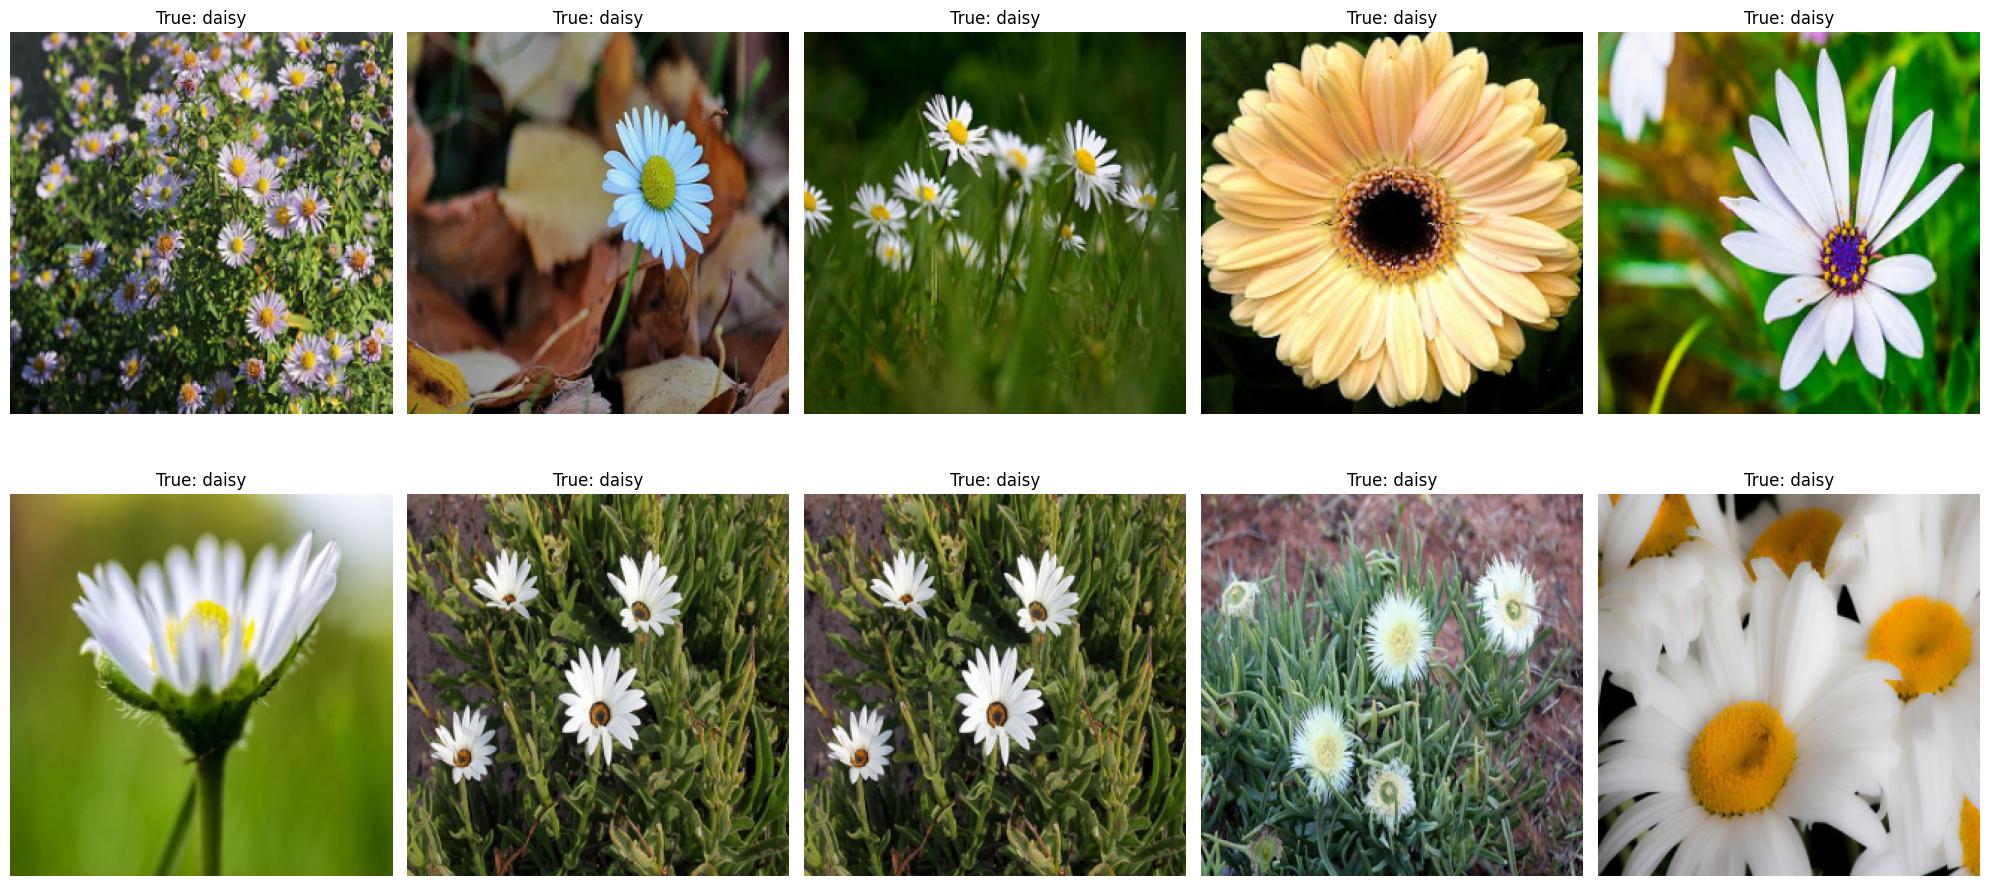

In [34]:
#First data exploration

print(f"Struttura del dataset: {os.listdir('./dataset/train')}")
 
trainset_defaultaug = trainset
trainset_defaultaug.transform = Transforms(default_preprocessing_pipeline)

for i in range(2):
    Helper.plot_images(trainset_defaultaug, trainset.classes, i, num_col=5, num_row=2)

del trainset_defaultaug